In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [24]:
df = pd.read_csv('medical_examination.csv')

In [25]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [26]:
df['overweight'] = (df['weight'] / ((df['height'] / 100) ** 2) > 25).astype(int)

In [27]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


In [28]:
df['gluc'] = df['gluc'].transform(lambda x: 0 if x == 1 else 1)
df['cholesterol'] = df['cholesterol'].transform(lambda x: 0 if x == 1 else 1)

In [29]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0


In [34]:
df_cat = pd.melt(df, id_vars=['cardio'], value_vars=[
    'cholesterol',
    'gluc',
    'smoke',
    'alco',
    'active',
    'overweight'
])

In [35]:
df_cat

,cardio,variable,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
...,...,...,...
419995,0,overweight,1
419996,1,overweight,1
419997,1,overweight,1
419998,1,overweight,1


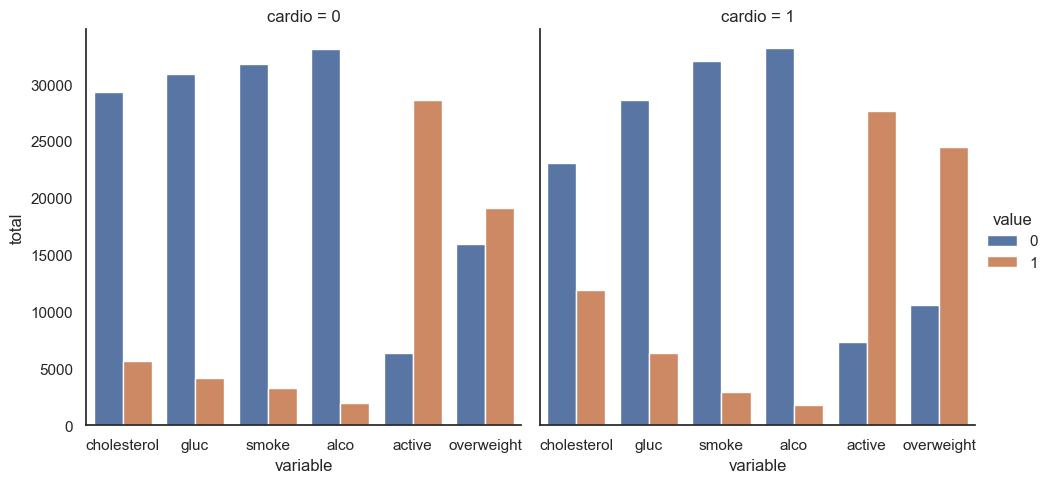

In [102]:
fig = sns.catplot(df_cat, kind='count', x='variable', hue='value', col='cardio')
fig.set_axis_labels('variable', 'total')

---

In [67]:
df.drop((df['ap_lo'] > df['ap_hi']).astype(int)).reset_index()

,index,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
1,3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
2,4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
3,5,8,21914,1,151,67.0,120,80,1,1,0,0,0,0,1
4,6,9,22113,1,157,93.0,130,80,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69994,69996,99995,22601,1,158,126.0,140,90,1,1,0,0,1,1,1
69995,69997,99996,19066,2,183,105.0,180,90,1,0,0,1,0,1,1
69996,69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


In [ ]:
# df_heat = df.drop((df['ap_lo'] > df['ap_hi']).astype(int)).reset_index(drop=True)

In [98]:
# (df_heat['height'] < df_heat['height'].quantile(0.025)).astype(int).value_counts()

height
0    68453
1     1537
Name: count, dtype: int64

In [74]:
# df_heat.drop((df_heat['height'] < df_heat['height'].quantile(0.025)).astype(int)).reset_index(drop=True)

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
1,8,21914,1,151,67.0,120,80,1,1,0,0,0,0,1
2,9,22113,1,157,93.0,130,80,1,0,0,0,1,0,1
3,12,22584,2,178,95.0,130,90,1,1,0,0,1,1,1
4,13,17668,1,158,71.0,110,70,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69991,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69992,99995,22601,1,158,126.0,140,90,1,1,0,0,1,1,1
69993,99996,19066,2,183,105.0,180,90,1,0,0,1,0,1,1
69994,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


In [104]:
df.loc[
    (df['ap_lo'] < df['ap_hi']) &
    (df['height'] > df['height'].quantile(0.025)) &
    (df['height'] < df['height'].quantile(0.975)) &
    (df['weight'] > df['weight'].quantile(0.025)) &
    (df['weight'] < df['weight'].quantile(0.975)), :
]

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,0,0,0,0,1,1,0
69994,99992,21074,1,165,80.0,150,80,0,0,0,0,1,1,1
69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


In [106]:
df_heat = df.loc[
    (df['ap_lo'] < df['ap_hi']) &
    (df['height'] > df['height'].quantile(0.025)) &
    (df['height'] < df['height'].quantile(0.975)) &
    (df['weight'] > df['weight'].quantile(0.025)) &
    (df['weight'] < df['weight'].quantile(0.975)), :
]

In [ ]:
# df_heat = df_heat.drop((df_heat['height'] < df_heat['height'].quantile(0.025)).astype(int)).reset_index(drop=True)

In [ ]:
# df_heat = df_heat.drop((df_heat['height'] > df_heat['height'].quantile(0.975)).astype(int)).reset_index(drop=True)

In [ ]:
# df_heat = df_heat.drop((df_heat['weight'] < df_heat['weight'].quantile(0.025)).astype(int)).reset_index(drop=True)

In [ ]:
# df_heat = df_heat.drop((df_heat['weight'] > df_heat['weight'].quantile(0.975)).astype(int)).reset_index(drop=True)

In [105]:
# df_heat.shape

(69990, 14)

In [107]:
df_heat.shape

(61203, 14)

In [108]:
corr = df_heat.corr()

In [109]:
mask = np.triu(np.ones_like(corr, dtype=bool))

<Axes: >

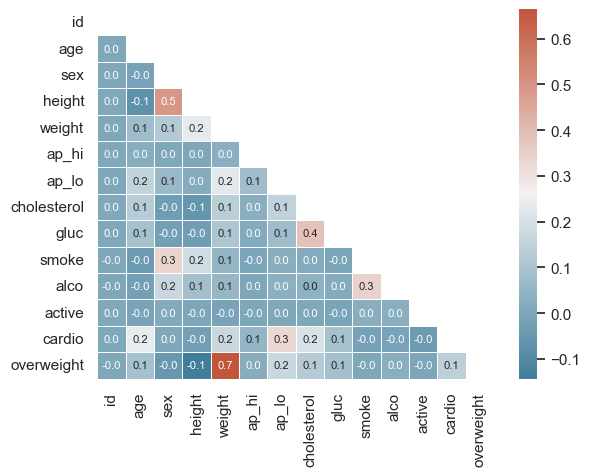

In [128]:
fig, ax = plt.subplots()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, linewidths=0.5, annot=True, fmt='.1f', annot_kws={'size': 8})

In [126]:
fig.axes[0].get_default_bbox_extra_artists()